# Expert knowledge integration with Structure Estimation

Structure learning in causal inference seeks to uncover the causal relationships among variables. Though common methods like the PC algorithm and Hill-climb Search are useful, they often struggle due to limited data and increasing compute time as the models become more complex. Incorporating expert knowledg enhances the accuracy of the learned structure, and also speeds up the strucutre estimation process as we discard models that do not agree with our prior knowledge.

This tutorial walks through the process of accommodating expert knowledge with the structure estimation capabilities of pgmpy. Expert knowledge is supported in pgmpy with the following algorithms:

- **PC**
- **Hill Climb Search**
- **GES**
- **MMHC**

The models used in this notebook are described in detail at [the bnlearn repository](https://www.bnlearn.com/bnrepository/).


### Expert knowledge with PC

In [18]:
from pgmpy.utils import get_example_model
from pgmpy.global_vars import logger
from IPython.display import display
import logging
import time

logger.setLevel(logging.ERROR)

  0%|          | 0/5 [00:00<?, ?it/s]

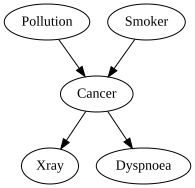

In [2]:
cancer = get_example_model("cancer")
cancer_samples = cancer.simulate(n_samples=5000, seed=42)

diag = cancer.to_graphviz()
diag.layout(prog="dot")
display(diag)

Normal PC run

  0%|          | 0/5 [00:00<?, ?it/s]

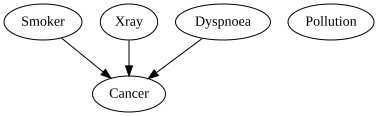

In [3]:
from pgmpy.estimators import PC, ExpertKnowledge

learned_model = PC(cancer_samples).estimate()

diag = learned_model.to_graphviz()
diag.layout(prog="dot")
display(diag)

As seen from the graph, the simulated samples are not enough to uncover the underlying graph accurately. Now, we know that smoking ('Smoker') and air pollution ('Pollution') contribute to lung cancer ('Cancer'). Also, breathing difficulties ('Dyspnoea') and a positive xray report ('Xray') contribute to a cancer diagnosis (effect), so they cannot be initial causes in this scenario. Based on this, we can craft a temporal order where the more causal nodes are at the beginning, while the effects are lumped together at the end.

  0%|          | 0/5 [00:00<?, ?it/s]

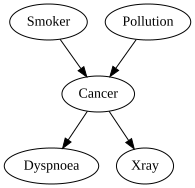

In [4]:
expert_knowledge = ExpertKnowledge(
    temporal_order=[["Pollution", "Smoker", "Cancer"], ["Dyspnoea", "Xray"]]
)
# e.g. we know only "Pollution", "Smoker", "Cancer" can be the causes of others

est_model = PC(cancer_samples).estimate(expert_knowledge=expert_knowledge)

diag = est_model.to_graphviz()
diag.layout(prog="dot")
display(diag)

Note: Using any form of expert knowledge, especially with PC, is sensitive to the accuracy of the knowledge.

### Integrating with different algorithms

  0%|          | 0/48 [00:00<?, ?it/s]

c:\Users\Nimish Purohit\pgmpy\.venv\Lib\site-packages\pygraphviz\agraph.py:1403: RuntimeWarning: Warning: pos attribute for edge (jordtype,nmin) doesn't have 3n+1 points

  warnings.warn(b"".join(errors).decode(self.encoding), RuntimeWarning)


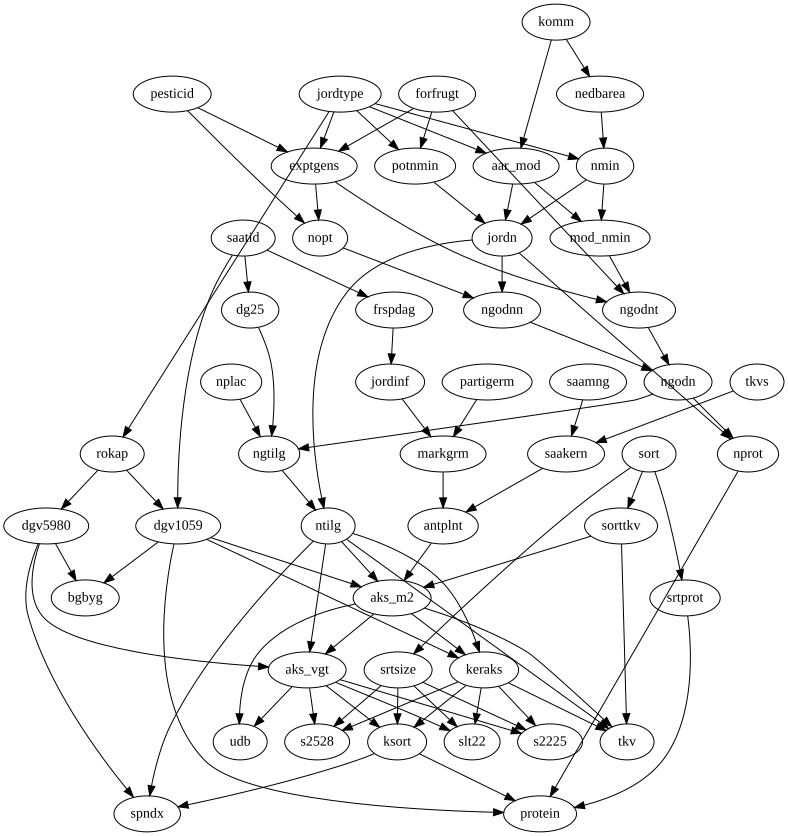

In [5]:
barley = get_example_model("barley")
barley_samples = barley.simulate(n_samples=5000, seed=42)

diag = barley.to_graphviz()
diag.layout(prog="dot")
display(diag)

In [6]:
from pgmpy.metrics import SHD

t1 = time.time()
est_model = PC(barley_samples).estimate()
t2 = time.time()
shd = SHD(barley, est_model)

print(f"Time elapsed: {t2-t1} seconds")
print(f"SHD: {shd}")

  0%|          | 0/5 [00:00<?, ?it/s]

Time elapsed: 87.46482706069946 seconds
SHD: 63


Combined approach

An alternative approach could be to first get a skeleton using the first phase of PC. The skeleton is simply the set of edges between nodes that are dependent(causal). This skeleton can be used as the search space for score-based methods like Hill Climb Search, thus reducing the workload in this phase (as we have already removed edges that are independent given some conditioning set). We get a reasonable result as compared to using only PC.

In [9]:
from pgmpy.estimators import HillClimbSearch

t1 = time.time()
skeleton, sep_sets = PC(barley_samples).estimate(return_type="skeleton")

expert_knowledge = ExpertKnowledge(search_space=skeleton.edges)
est_model = HillClimbSearch(barley_samples).estimate(expert_knowledge=expert_knowledge)
t2 = time.time()
shd = SHD(barley, est_model)

print(f"Time elapsed: {t2-t1} seconds")
print(f"SHD: {shd}")

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

Time elapsed: 86.24240565299988 seconds
SHD: 72


### Knowledge base of required and forbidden edges

  0%|          | 0/20 [00:00<?, ?it/s]

c:\Users\Nimish Purohit\pgmpy\.venv\Lib\site-packages\pygraphviz\agraph.py:1403: RuntimeWarning: Warning: pos attribute for edge (LungParench,Grunting) doesn't have 3n+1 points

  warnings.warn(b"".join(errors).decode(self.encoding), RuntimeWarning)


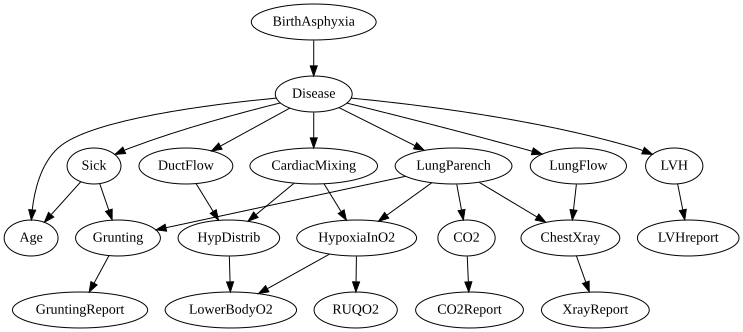

In [12]:
child = get_example_model("child")
child_samples = child.simulate(n_samples=1000, seed=42)

diag = child.to_graphviz()
diag.layout(prog="dot")
display(diag)

Based on similar reasoning as in the first section, we can now create a knowledge base consisting of forbidden and required edges. For example, having birth asphyxia ('Disease') directly contributes to the 6 subclassses/markers of disease ('LVH', 'LungParench' etc.). Similarly, the CO2 level ('CO2') affects the CO2 report ('CO2Report'), and not the other way around.

In [16]:
required_edges = [
    ("Disease", "Sick"),
    ("Disease", "DuctFlow"),
    ("Disease", "LungFlow"),
    ("Disease", "LungParench"),
    ("CO2", "CO2Report"),
]
forbidden_edges = [
    ("CO2Report", "CO2"),
    ("LVH", "Disease"),
    ("Disease", "BirthAsphyxia"),
]

expert_knowledge = ExpertKnowledge(
    required_edges=required_edges, forbidden_edges=forbidden_edges
)
est_model = HillClimbSearch(child_samples).estimate(
    expert_knowledge=expert_knowledge, scoring_method="k2"
)
SHD(child, est_model)

  0%|          | 0/1000000 [00:00<?, ?it/s]

4

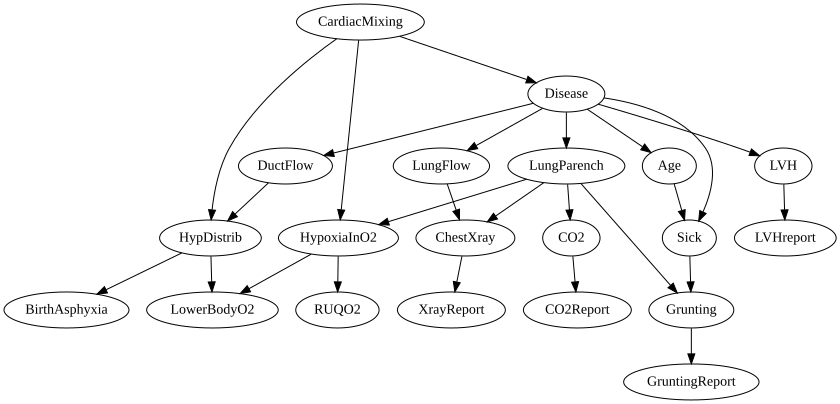

In [17]:
diag = est_model.to_graphviz()
diag.layout(prog="dot")
display(diag)